# 02 · Regime Detection
Train the Gaussian HMM, decode regimes, and explore the results interactively.

In [2]:
import sys, pathlib

from rich.jupyter import display

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt

from src.data_loader import download_price_data, load_close_series
from src.feature_engineering import build_feature_matrix
from src.hmm_model import (
    build_hmm, fit_hmm, predict_states, build_regime_dataframe, compute_extended_statistics, analyze_regime_durations, compute_persistence_score, print_model_diagnostics, save_model, load_model, profile_regimes, compute_state_statistics, label_states
)

from src.visualization import (
    plot_closing_price, plot_price_by_regime,
    plot_return_histograms, plot_transition_matrix, plot_regime_timeline
)
from src.utils import configure_logging, resolve_path, print_state_statistics

configure_logging()
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [3]:
TICKER = 'INFY.NS'
START  = '2010-01-01'
END    = '2026-06-01'

raw   = download_price_data(TICKER, START, END, resolve_path('data', 'raw'))
close = load_close_series(raw)
log_returns, X, scaler = build_feature_matrix(close)
print(f'Feature matrix: {X.shape}')

22:18:40  INFO      src.data_loader — Loading cached data from /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/data/raw/INFY.NS_2010-01-01_2026-06-01.csv
22:18:40  INFO      src.feature_engineering — Computed 4049 log-return observations (0.0004 mean, 0.017202 std)
22:18:40  INFO      src.feature_engineering — Features standardised — mean≈-0.0000, std≈1.0000
Feature matrix: (4049, 1)


In [4]:
model = build_hmm()
model = fit_hmm(model, X)
states = predict_states(model, X)
print_model_diagnostics(model)

22:18:42  INFO      src.hmm_model — Fitting HMM with 3 components …
22:18:42  INFO      src.hmm_model — HMM fitted — log-likelihood: -5206.9449
22:18:42  INFO      src.hmm_model —   State 0 — 1934 observations (47.8%)
22:18:42  INFO      src.hmm_model —   State 1 — 1943 observations (48.0%)
22:18:42  INFO      src.hmm_model —   State 2 — 172 observations (4.2%)

HMM MODEL DIAGNOSTICS

▸ Initial state probabilities  (model.startprob_)
    State 0: 0.0001
    State 1: 0.9999
    State 2: 0.0000

▸ State transition matrix  (model.transmat_)
         → S0  → S1  → S2
  S0 →  0.0053  0.9945  0.0002
  S1 →  0.9104  0.0137  0.0760
  S2 →  0.3728  0.1166  0.5106

▸ Emission means  (model.means_)
    State 0: 0.012857
    State 1: 0.026067
    State 2: -0.248008



In [5]:
stats     = compute_state_statistics(log_returns, states)
labels    = label_states(stats)
regime_df = build_regime_dataframe(log_returns, states, labels)
print_state_statistics(stats, labels)

22:18:43  INFO      src.hmm_model — Derived regime labels: {0: 'Low Volatility Bull', 2: 'Crash / Bear Regime', 1: 'High Volatility Bull'}

REGIME SUMMARY STATISTICS
                     Mean Return Volatility  Count Frequency
Regime                                                      
Low Volatility Bull     0.000499   0.012473  1,934    47.76%
High Volatility Bull    0.000890   0.013365  1,943    47.99%
Crash / Bear Regime    -0.006050   0.056328    172     4.25%



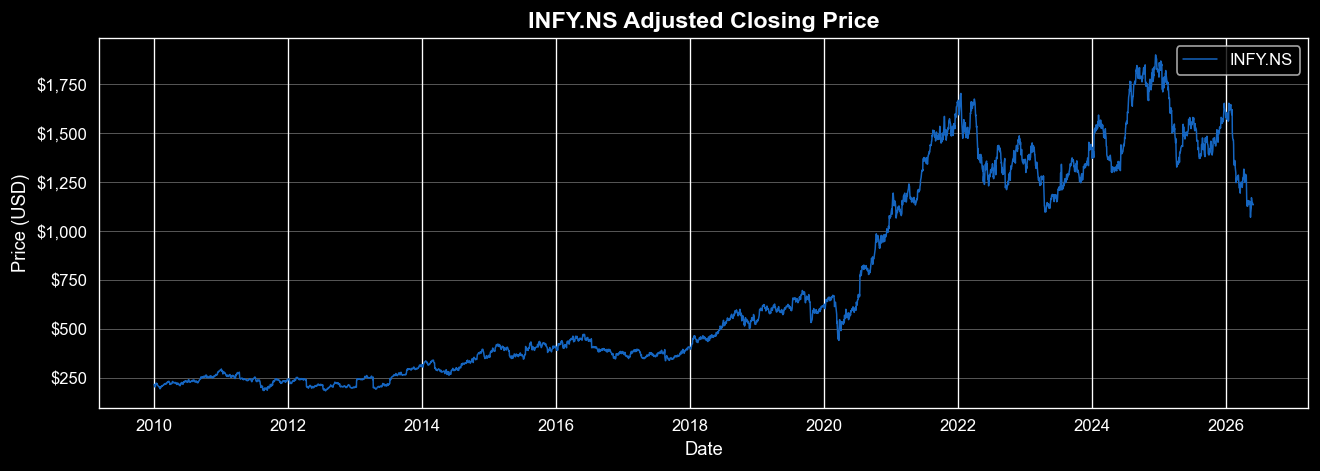

In [6]:
fig = plot_closing_price(close, TICKER)
plt.show()

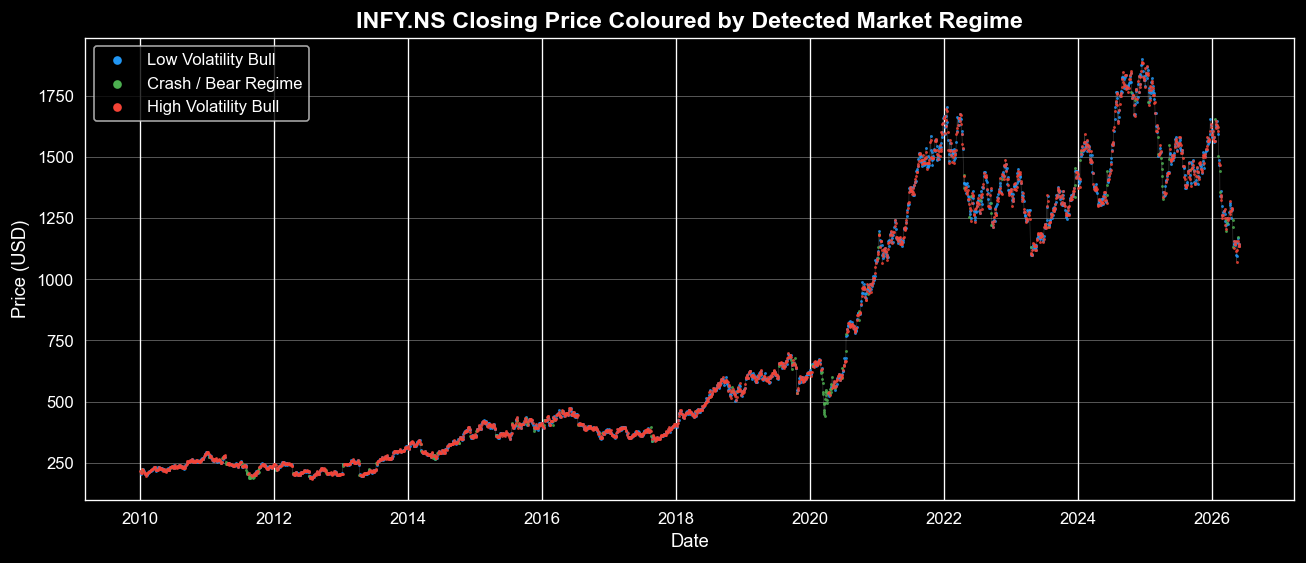

In [7]:
fig = plot_price_by_regime(close, regime_df, labels, TICKER)
plt.show()

### Added Features: Regime Statistics, Durations, and Profiling

In [8]:
from IPython.display import display

ext_stats = compute_extended_statistics(regime_df, labels)
ext_stats.to_csv(resolve_path('outputs', 'regime_statistics.csv'), index=False)
display(ext_stats)

,Regime,Mean Daily Return,Median Daily Return,Daily Volatility,Annualized Volatility,Sharpe Ratio,Max Daily Gain,Max Daily Loss,Number of Observations,Frequency Percentage
0,Low Volatility Bull,0.000499,0.000221,0.012473,0.198005,0.635032,0.038705,-0.039421,1934,47.764880
1,Crash / Bear Regime,-0.006050,-0.017970,0.056328,0.894184,-1.705018,0.155165,-0.239001,172,4.247962
2,High Volatility Bull,0.000890,0.000932,0.013365,0.212162,1.056996,0.045899,-0.044387,1943,47.987157


In [9]:
durations = analyze_regime_durations(regime_df, labels)
durations.to_csv(resolve_path('outputs', 'regime_durations.csv'), index=False)
display(durations)

,Regime,Mean Duration,Median Duration,Maximum Duration,Std Dev of Duration
0,Low Volatility Bull,1.00,1.0,1,0.000000
1,Crash / Bear Regime,2.15,2.0,20,2.356374
2,High Volatility Bull,1.00,1.0,1,0.000000


In [10]:
persistence = compute_persistence_score(model.transmat_, durations, labels)
display(persistence)

profile_regimes(ext_stats, persistence, labels, resolve_path('outputs', 'regime_profiles.md'))

,State,Expected Duration,Empirical Duration
0,Low Volatility Bull,1.005317,1.00
1,Crash / Bear Regime,2.043225,2.15
2,High Volatility Bull,1.013870,1.00


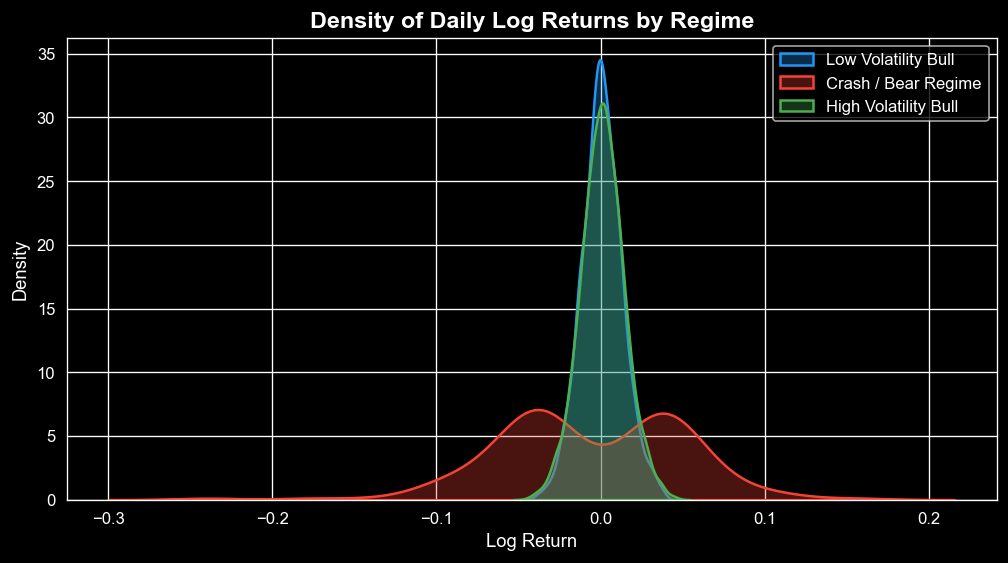

In [11]:
fig = plot_return_histograms(regime_df, labels)
plt.show()

In [12]:
fig_tm = plot_transition_matrix(
    model.transmat_,
    save_path=resolve_path('outputs', 'figures', 'transition_matrix.png')
)
plt.show()

22:18:59  INFO      src.visualization — Figure saved → /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/outputs/figures/transition_matrix.png


In [13]:
fig_tl = plot_regime_timeline(close, regime_df, labels, save_path=resolve_path('outputs', 'figures', 'regime_timeline.png'))
plt.show()

22:19:01  INFO      src.visualization — Figure saved → /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/outputs/figures/regime_timeline.png


In [14]:
save_model(model, resolve_path('outputs', 'models', f'hmm_{TICKER.lower()}.pkl'))
regime_df.to_csv(resolve_path('outputs', f'regime_labels_{TICKER.lower()}.csv'))
print('Artefacts saved.')

22:19:02  INFO      src.hmm_model — Model saved to /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/outputs/models/hmm_infy.ns.pkl
Artefacts saved.
